<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin-right: 20px; height: 55px" height="55px">

# 2. Advanced Chunking, Embeddings & Indexing

**Duration:** 40 - 50 minutes

---

## Module Guide

1. [Adaptive Chunking Heuristics for Structured and Unstructured Data](#heuristics)
2. [Choosing Embedding Models by Domain, Language, and Cost](#embedding-models)
3. [Configuring and Tuning Vector Store Parameters for Performance and Scalability](#tuning)

---

## Learning Objectives

1. Apply adaptive chunking heuristics to optimize the retrieval quality of both structured and unstructured data.
2. Evaluate and select embedding models based on domain specificity, multilingual needs, and cost-performance trade-offs.
3. Implement scalable indexing patterns — HNSW, IVF-Flat, and hybrid indices — and optimize memory usage for high-performance vector search.

**Setup:** this notebook uses `faiss-cpu` and `numpy`. Run the cell below first.

In [1]:
%pip install faiss-cpu numpy langchain-text-splitters langchain-openai langchain-huggingface langchain-pinecone pinecone

In [2]:
import os
import getpass

# Set your OpenAI API Key here if you have one. This is optional.
openai_key = getpass.getpass("Enter your OpenAI API Key (leave empty to skip): ")
if openai_key:
    os.environ["OPENAI_API_KEY"] = openai_key

# Set your Pinecone API Key here if you have one. This is optional.
pinecone_key = getpass.getpass("Enter your Pinecone API Key (leave empty to skip): ")
if pinecone_key:
    os.environ["PINECONE_API_KEY"] = pinecone_key

print("API key input prompts added.")

Enter your OpenAI API Key (leave empty to skip): ··········
Enter your Pinecone API Key (leave empty to skip): ··········
API key input prompts added.


<h2 id="heuristics"> 2.1 - Adaptive Chunking Heuristics for Structured and Unstructured Data </h2>

"Chunking" is often taught as if one algorithm applies uniformly to an entire corpus. In practice, a real document collection is never homogeneous — a single knowledge base might contain narrative prose, markdown pages with nested headers, code blocks, and tables in the same folder. **Adaptive chunking** means detecting what *kind* of content a document (or even a section of a document) actually is, and routing it to the chunking strategy suited to that shape, rather than running every byte of text through the same fixed-size splitter.

Three chunking strategies, and when each is the right adaptive choice:

| Strategy | Best suited for | Weak point if misapplied |
|---|---|---|
| **Fixed-size / recursive character splitting** | Uniform prose with no strong internal structure (chat transcripts, casual notes) | Slices tables mid-row, splits code blocks, severs a definition from its example |
| **Semantic chunking** (split where sentence-embedding distance spikes) | Long-form narrative or explanatory prose where topic shifts are gradual (articles, book chapters) | Expensive to compute at scale (an embedding call per sentence boundary); can misfire on text with abrupt style changes that aren't real topic changes |
| **Structure-aware / parent-child chunking** (respect markdown headers, table boundaries, code fences) | Technical documentation, contracts, financial filings — anything with explicit structural markers | Requires a parser per document type; doesn't help with genuinely unstructured free text |

An adaptive chunker is, at its core, a **router with a chunking strategy behind each branch** — structurally similar to the query router from Module 1, except it classifies *document content* instead of *queries*. A practical, easily explainable detection pipeline:

1. Detect **structural markers** first (Markdown headers, HTML tags, triple-backtick code fences, table delimiters like `|` or repeated tab characters). If present, use structure-aware chunking on that section.
2. For remaining prose sections with no structural markers, fall back to semantic chunking if the section is long enough to have genuine topic drift (say, more than ~5 sentences); otherwise fixed-size chunking is fine and cheaper.
3. Always attach chunk-level metadata (source section, heading path, content type) regardless of which strategy produced the chunk — this metadata becomes the pre-filtering substrate from Module 1.

**Chunking strategies(conceptually):**

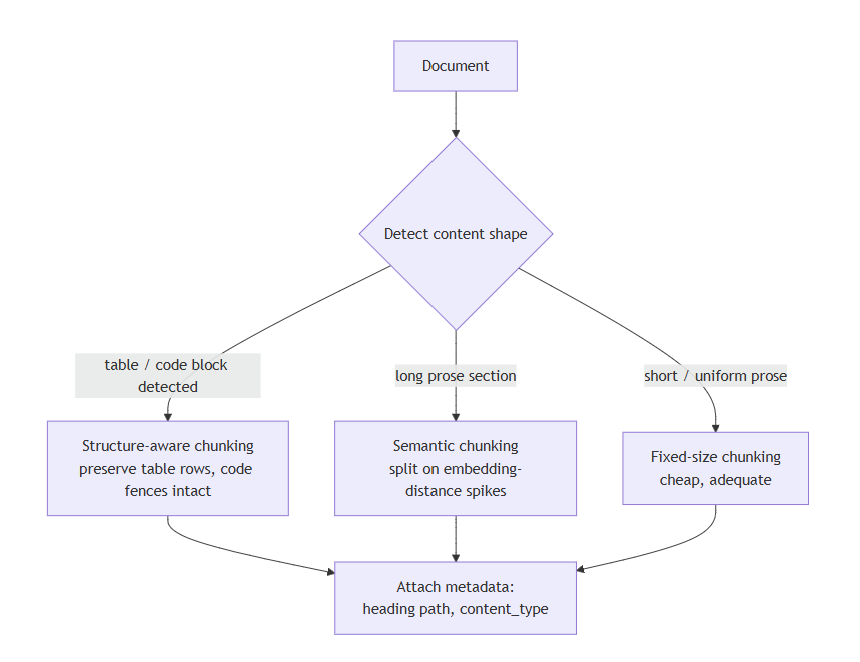

### Practical Application — Technical Documentation Knowledge Base

An internal engineering docs site mixes narrative explanation, fenced code samples, and CLI reference tables in the same Markdown files. Fixed-size chunking applied uniformly will regularly slice a code sample in half — producing a chunk with an opening `def foo(` and no closing brace, which is useless once retrieved and shown to a generator (or a human). An adaptive chunker detects the triple-backtick fence and treats everything between the fences as one atomic, unsplittable chunk (or attaches it wholesale to its preceding explanatory paragraph as a parent-child pair), while the surrounding prose is still free to be split normally.

### Example

**Task:** Build an adaptive chunker that detects code blocks and tables, routes them to a structure-preserving strategy, and falls back to fixed-size chunking for ordinary prose — then verify each output chunk has the correct `content_type` tag.

In [3]:
import re

CODE_FENCE_PATTERN = re.compile(r"```.*?```", re.DOTALL)
TABLE_ROW_PATTERN = re.compile(r"^\s*\|.*\|\s*$", re.MULTILINE)

def fixed_size_chunk(text: str, chunk_size: int = 200) -> list[str]:
    words = text.split()
    chunks, current = [], []
    current_len = 0
    for word in words:
        current.append(word)
        current_len += len(word) + 1
        if current_len >= chunk_size:
            chunks.append(" ".join(current))
            current, current_len = [], 0
    if current:
        chunks.append(" ".join(current))
    return chunks


def adaptive_chunk(document: str) -> list[dict]:
    """
    Detects code fences and markdown tables first, treats them as atomic
    structure-preserving chunks, and fixed-size chunks everything else.
    """
    chunks = []
    remaining = document
    cursor = 0

    # collect all structural spans (code fences and contiguous table blocks)
    spans = []
    for match in CODE_FENCE_PATTERN.finditer(document):
        spans.append((match.start(), match.end(), "code"))

    table_rows = list(TABLE_ROW_PATTERN.finditer(document))
    if table_rows:
        block_start = table_rows[0].start()
        block_end = table_rows[0].end()
        for row in table_rows[1:]:
            if row.start() <= block_end + 2:   # contiguous rows -> same table block
                block_end = row.end()
            else:
                spans.append((block_start, block_end, "table"))
                block_start, block_end = row.start(), row.end()
        spans.append((block_start, block_end, "table"))

    spans.sort()

    for start, end, content_type in spans:
        if start > cursor:
            prose = document[cursor:start].strip()
            if prose:
                for c in fixed_size_chunk(prose):
                    chunks.append({"text": c, "content_type": "prose"})
        chunks.append({"text": document[start:end].strip(), "content_type": content_type})
        cursor = end

    if cursor < len(document):
        prose = document[cursor:].strip()
        if prose:
            for c in fixed_size_chunk(prose):
                chunks.append({"text": c, "content_type": "prose"})

    return chunks


sample_doc = """This function resets a user's session token when called.

```python
def reset_token(user_id):
    return generate_new_token(user_id)
```

The table below lists the supported error codes.

| Code | Meaning |
| 401  | Unauthorized |
| 403  | Forbidden |

Call this endpoint only after verifying the user's identity through SSO."""

for chunk in adaptive_chunk(sample_doc):
    print(f"[{chunk['content_type']:6}] {chunk['text'][:60]!r}")


[prose ] "This function resets a user's session token when called."
[code  ] '```python\ndef reset_token(user_id):\n    return generate_new_'
[prose ] 'The table below lists the supported error codes.'
[table ] '| Code | Meaning |\n| 401  | Unauthorized |\n| 403  | Forbidde'
[prose ] "Call this endpoint only after verifying the user's identity "


Running this produces three distinct `content_type` tags — `prose`, `code`, and `table` — with the code block and table rows preserved intact rather than fragmented. That `content_type` tag is exactly the kind of chunk-level metadata that later feeds Module 1's pre-filtering stage (e.g., "only retrieve `code` chunks for an API-reference query").

### Now you try - exercise

**Task:** Extend `adaptive_chunk` to also detect **Markdown headers** (`#`, `##`, `###`) and attach a `heading_path` field to every chunk showing the full header hierarchy above it (e.g., `"Setup > Authentication > Token Refresh"`), not just a flat `content_type` tag. Specifically:

1. Track the current stack of open headers as you scan through the document top to bottom (a `#` resets the whole stack; a `##` replaces anything below the current `#`; and so on).
2. Every chunk emitted (prose, code, or table) should carry a `heading_path` string built from the currently active header stack at that point in the document.
3. Verify against a test document containing at least two levels of nested headers, one code block under a sub-heading, and confirm the code block's `heading_path` correctly reflects both the parent and child heading.

Fill in every function marked `TODO` / `NotImplementedError` below. If you get stuck, the fully worked version of this notebook is at `/solutions/02_chunking_embeddings_indexing_solution.ipynb`.

In [4]:
import re

CODE_FENCE_PATTERN = re.compile(r"```.*?```", re.DOTALL)
TABLE_ROW_PATTERN = re.compile(r"^\s*\|.*\|\s*$", re.MULTILINE)
HEADER_PATTERN = re.compile(r"^(#{1,6})\s+(.*)$", re.MULTILINE)

def fixed_size_chunk(text: str, chunk_size: int = 200) -> list:
    words = text.split()
    chunks, current = [], []
    current_len = 0
    for word in words:
        current.append(word)
        current_len += len(word) + 1
        if current_len >= chunk_size:
            chunks.append(" ".join(current))
            current, current_len = [], 0
    if current:
        chunks.append(" ".join(current))
    return chunks


def merge_table_spans(document: str) -> list:
    table_rows = list(TABLE_ROW_PATTERN.finditer(document))
    spans = []
    if table_rows:
        block_start = table_rows[0].start()
        block_end = table_rows[0].end()
        for row in table_rows[1:]:
            if row.start() <= block_end + 2:
                block_end = row.end()
            else:
                spans.append((block_start, block_end, "table"))
                block_start, block_end = row.start(), row.end()
        spans.append((block_start, block_end, "table"))
    return spans

def adaptive_chunk_v2(document: str) -> list:
    events = []
    for m in HEADER_PATTERN.finditer(document):
        events.append((m.start(), m.end(), "header", len(m.group(1)), m.group(2).strip()))
    for m in CODE_FENCE_PATTERN.finditer(document):
        events.append((m.start(), m.end(), "code", None, None))
    for start, end, _ in merge_table_spans(document):
        events.append((start, end, "table", None, None))

    events.sort(key=lambda e: e[0])

    chunks = []
    stack = []   # (level, title), most-specific last
    cursor = 0

    def heading_path():
        return " > ".join(title for _, title in stack) if stack else None

    def emit_prose(text_slice):
        text_slice = text_slice.strip()
        if text_slice:
            for c in fixed_size_chunk(text_slice):
                chunks.append({"text": c, "content_type": "prose", "heading_path": heading_path()})

    for start, end, kind, level, title in events:
        if start > cursor:
            emit_prose(document[cursor:start])

        if kind == "header":
            stack = [item for item in stack if item[0] < level]
            stack.append((level, title))
        else:
            chunks.append({"text": document[start:end].strip(), "content_type": kind, "heading_path": heading_path()})

        cursor = end

    if cursor < len(document):
        emit_prose(document[cursor:])

    return chunks


In [5]:
# Verification -- do not modify.
doc = """# Setup

Some intro text about setup.

## Authentication

Explains how authentication works in general.

### Token Refresh

Here is how you refresh a token.

```python
def refresh(token):
    return new_token(token)
```

## Deployment

Deployment notes go here."""

for c in adaptive_chunk_v2(doc):
    print(f"{c['content_type']:6} | {str(c['heading_path']):45} | {c['text'][:40].strip()!r}")

# Expected: the code block's heading_path should be "Setup > Authentication > Token Refresh"
# and the final prose chunk's heading_path should be "Setup > Deployment"


prose  | Setup                                         | 'Some intro text about setup.'
prose  | Setup > Authentication                        | 'Explains how authentication works in gen'
prose  | Setup > Authentication > Token Refresh        | 'Here is how you refresh a token.'
code   | Setup > Authentication > Token Refresh        | '```python\ndef refresh(token):\n    return'
prose  | Setup > Deployment                            | 'Deployment notes go here.'


<h2 id="embedding-models"> 2.2 - Choosing Embedding Models by Domain, Language, and Cost </h2>


There is no universally "best" embedding model — only trade-offs along three axes: **cost and latency** (API call vs. local inference), **domain fit** (does the model differentiate the vocabulary that actually matters in your corpus), and **multilingual coverage**. But a fourth, less-discussed axis matters just as much in practice: **the shape of the content you're embedding is not uniform**, and treating every input as "just text to embed" produces silently worse retrieval for several common content types.

Consider four genuinely different content shapes you are likely to encounter in the same organization:

| Content type | Defining characteristic | Embedding implication |
|---|---|---|
| **A full-length book** (hundreds of pages) | Long-range narrative structure; a single chapter can be 5,000+ words | Cannot be embedded as one vector — must be chunked first, and retrieval quality depends heavily on chunk boundaries preserving enough local context to be meaningful in isolation |
| **A research paper with tables and charts** | Dense, information-packed sections interleaved with non-prose elements (tables, figure captions, equations) | Tables and figures need to be extracted and *serialized* into a text-representable form (e.g., a table converted to a Markdown table or a sentence-per-row description) before embedding — a raw PDF-to-text dump of a table often collapses into unreadable, unembeddable noise |
| **A tweet / short social post** | Extremely short (often under 280 characters), high context-density, frequently relies on external context (hashtags, replies, links) that isn't in the text itself | A single tweet is usually embedded as one atomic unit (no chunking needed), but similarity thresholds that work for paragraph-length text are often miscalibrated for short text — short texts cluster more tightly in embedding space, so a "0.8 similarity is a strong match" heuristic tuned on long documents will over-match on tweets |
| **Metadata tags for a media library** (e.g., `["action", "1990s", "sci-fi", "practical-effects"]`) | Not natural-language prose at all — a small, structured, often-controlled vocabulary | Naively joining tags with commas and embedding the result as a sentence often under-utilizes the embedding model, which was trained on natural language; better results usually come from either a lightweight tag-co-occurrence/keyword model, or from constructing a synthetic natural-language sentence from the tags (e.g., "A 1990s action film featuring practical effects") before embedding |



> The practical takeaway: **embedding model selection is not just "which model" — it's "which model, applied to which representation of the content."** Choosing `text-embedding-3-large` for both a novel and a tag list solves only half the problem if the tag list is still being embedded as a raw comma-joined string.

**Embedding model selection (conceptually):**

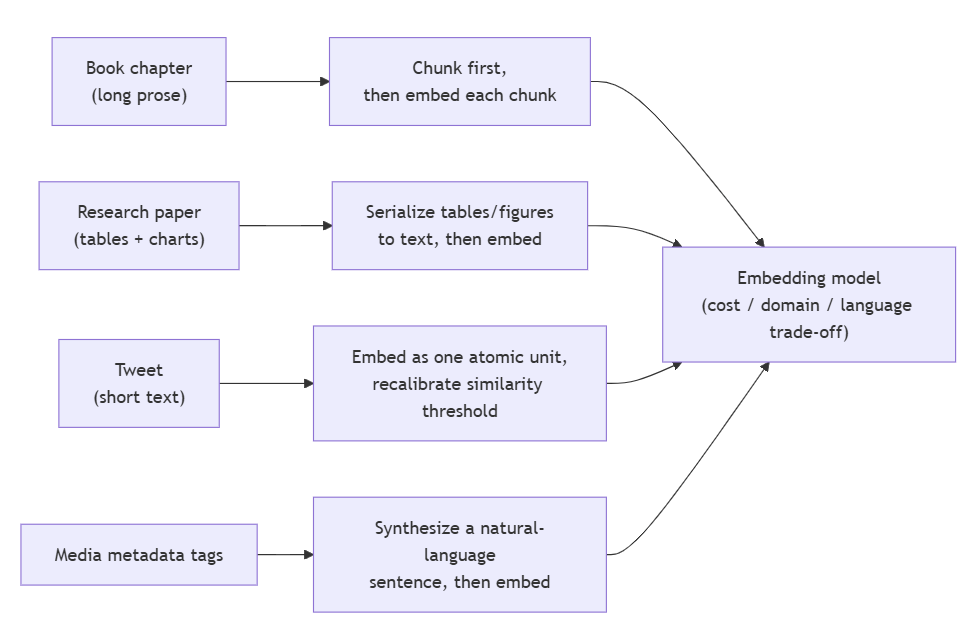

### Practical Application — Streaming Media Library Search ("find me something like X")

A video streaming platform's recommendation-adjacent search feature needs to match a user's natural-language query ("something like Blade Runner but funnier") against a catalog whose only structured signal is a list of metadata tags per title. Embedding the raw tag list (`"neo-noir, dystopian, android, 1980s, cult-classic"`) as a comma-joined string produces a noticeably weaker match against natural-language queries than first synthesizing a descriptive sentence from the tags (`"A neo-noir dystopian film from the 1980s about androids, now considered a cult classic"`) and embedding that instead — because the query and the synthetic description now share the same natural-language "shape" that the embedding model was actually trained on.

### Example

**Task:** Build a content-type-aware embedding preprocessor that applies a different text-representation strategy per content type, then use a small deterministic embedding stand-in to demonstrate the representations are meaningfully different before they ever reach a real embedding model.

In [6]:
import hashlib
import numpy as np

def fake_embed(text: str, dim: int = 16) -> np.ndarray:
    """
    Deterministic, dependency-free stand-in for a real embedding call
    (e.g., OpenAI's text-embedding-3-small or a local sentence-transformer).
    Same text always maps to the same vector, and similar text produces
    correlated vectors via shared word hashing -- good enough to demonstrate
    preprocessing effects without requiring model downloads in this lab.
    """
    vec = np.zeros(dim)
    for word in text.lower().split():
        h = int(hashlib.md5(word.encode()).hexdigest(), 16)
        vec[h % dim] += 1.0
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec


def prepare_for_embedding(content: dict) -> str:
    """
    content: {"type": "book" | "paper_table" | "tweet" | "media_tags", ...}
    Returns the text representation that should actually be sent to the
    embedding model -- not necessarily the raw input.
    """
    content_type = content["type"]

    if content_type == "media_tags":
        tags = content["tags"]
        # synthesize a natural-language sentence instead of comma-joining
        return f"A {' '.join(tags[:-1])} film featuring {tags[-1]}."

    if content_type == "paper_table":
        # serialize a table row into a self-describing sentence
        row = content["row"]
        return (f"On the {content['benchmark']} benchmark, "
                f"{row['model']} achieves an F1 score of {row['f1']}.")

    if content_type == "tweet":
        # embedded as-is, atomic, no chunking
        return content["text"]

    if content_type == "book_chapter":
        # in a real pipeline this would already have been chunked;
        # here we just pass the chunk through unchanged
        return content["chunk_text"]

    raise ValueError(f"Unknown content type: {content_type}")


samples = [
    {"type": "media_tags", "tags": ["neo-noir", "dystopian", "1980s", "androids"]},
    {"type": "paper_table", "benchmark": "CoNLL-2003", "row": {"model": "Model X", "f1": 92.4}},
    {"type": "tweet", "text": "Outage on the payments API, investigating now. #incident"},
    {"type": "book_chapter", "chunk_text": "The old lighthouse keeper had not spoken to another soul in three winters."},
]

for sample in samples:
    representation = prepare_for_embedding(sample)
    vector = fake_embed(representation)
    print(f"[{sample['type']:12}] representation={representation!r}")
    print(f"{'':14} embedding preview: {np.round(vector[:5], 3)}\n")


[media_tags  ] representation='A neo-noir dystopian 1980s film featuring androids.'
               embedding preview: [0.    0.277 0.    0.    0.   ]

[paper_table ] representation='On the CoNLL-2003 benchmark, Model X achieves an F1 score of 92.4.'
               embedding preview: [0.5  0.25 0.25 0.   0.25]

[tweet       ] representation='Outage on the payments API, investigating now. #incident'
               embedding preview: [0.802 0.    0.    0.    0.   ]

[book_chapter] representation='The old lighthouse keeper had not spoken to another soul in three winters.'
               embedding preview: [0.243 0.243 0.243 0.485 0.   ]



Running this prints, for each content type, the actual text representation that would be sent to a real embedding model — making visible the point where a naive pipeline would have instead embedded a raw comma-joined tag string or an unstructured table dump.

### Now you try - exercise

**Task:** Extend `prepare_for_embedding` (and the `samples` list) to correctly handle a fifth content type: **product reviews**, which have their own distinct shape — a short free-text body, a 1-5 star rating, and sometimes a "verified purchase" flag. Specifically:

1. Add a `"product_review"` branch that constructs a representation combining the rating and the review text in a way that preserves the rating as *retrievable signal* rather than discarding it (e.g., a query like "reviews complaining about battery life" should be able to distinguish a 1-star battery complaint from a 5-star one that happens to mention "battery" positively).
2. Justify in a comment why you chose to prepend, append, or otherwise encode the rating rather than dropping it — there is more than one reasonable answer here, but it must be a deliberate choice, not an omission.
3. Add at least 2 sample product reviews (one negative, one positive) to the `samples` list and confirm both produce distinct, sensible representations when printed.

In [7]:
import hashlib
import numpy as np

def fake_embed(text: str, dim: int = 16) -> np.ndarray:
    vec = np.zeros(dim)
    for word in text.lower().split():
        h = int(hashlib.md5(word.encode()).hexdigest(), 16)
        vec[h % dim] += 1.0
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0 else vec


def prepare_for_embedding_v2(content: dict) -> str:
    content_type = content["type"]

    if content_type == "product_review":
        # Prepend the rating as an explicit natural-language qualifier rather than
        # appending it or dropping it: this places the sentiment-bearing word
        # ("poor"/"excellent") immediately next to the topic words the review
        # discusses, so a proximity-sensitive similarity function weighs rating
        # and content together rather than the rating getting diluted at the far
        # end of a long review body.
        rating = content["rating"]
        quality_word = {1: "poor", 2: "below average", 3: "average", 4: "good", 5: "excellent"}[rating]
        verified = "Verified purchase. " if content.get("verified") else ""
        return f"{verified}{quality_word} ({rating}/5 stars) review: {content['text']}"

    if content_type == "media_tags":
        tags = content["tags"]
        return f"A {' '.join(tags[:-1])} film featuring {tags[-1]}."

    if content_type == "paper_table":
        row = content["row"]
        return (f"On the {content['benchmark']} benchmark, "
                f"{row['model']} achieves an F1 score of {row['f1']}.")

    if content_type == "tweet":
        return content["text"]

    if content_type == "book_chapter":
        return content["chunk_text"]

    raise ValueError(f"Unknown content type: {content_type}")

In [8]:
# Add at least 2 product review samples (one negative, one positive) and verify
# they produce distinct, sensible representations and embeddings.
samples = [
    {"type": "product_review", "rating": 1, "verified": True,
     "text": "Battery life is abysmal, dead by lunchtime every single day."},
    {"type": "product_review", "rating": 5, "verified": True,
     "text": "Battery easily lasts two full days, very impressed."},
]

for sample in samples:
    representation = prepare_for_embedding_v2(sample)
    print(f"representation={representation!r}")

v1 = fake_embed(prepare_for_embedding_v2(samples[0]))
v2 = fake_embed(prepare_for_embedding_v2(samples[1]))
cos_sim = float(np.dot(v1, v2))
print(f"\nCosine similarity between the 1-star and 5-star battery reviews: {cos_sim:.3f}")
assert cos_sim < 0.99, "Reviews should not be nearly identical vectors"
print("Confirmed: opposite-sentiment reviews are distinguishable in embedding space.")


representation='Verified purchase. poor (1/5 stars) review: Battery life is abysmal, dead by lunchtime every single day.'
representation='Verified purchase. excellent (5/5 stars) review: Battery easily lasts two full days, very impressed.'

Cosine similarity between the 1-star and 5-star battery reviews: 0.544
Confirmed: opposite-sentiment reviews are distinguishable in embedding space.



<h2 id="scalable-indexing"> 2.3 — Scalable Indexing: HNSW, IVF-Flat, and Memory-Aware Index Selection </h2>


Once you have chunks and embeddings, you need an index that can search millions of vectors in milliseconds — and the right index is not a matter of taste, it's a function of three concrete questions, in the order FAISS's own index-selection guidelines pose them:

1. **How many searches will you run?** If you'll only ever run a handful of searches (hundreds to low thousands) against a given index build, the cost of building any fancy index structure is never amortized — a brute-force `Flat` index (exact, no approximation) is simplest and often faster in wall-clock terms than building an approximate index you'll barely use.
2. **Do you need exact results?** If yes, `Flat` is your only option — it is the only index type that guarantees the true top-k, and it is also the ground-truth baseline you should benchmark every approximate index against.
3. **If approximate results are acceptable, is memory a concern?** This is where most production decisions actually live:
   - **Memory is not a concern (or the dataset is small):** `HNSW` is the standard recommendation — very fast and accurate, at the cost of roughly `(dimension × 4 + M × 2 × 4)` bytes per vector, where `M` (typically 4–64) controls the number of graph links per node.
   - **Memory matters somewhat:** an `IVF,Flat` index — vectors are clustered (via k-means) into partitions, and a query only searches the `nprobe` most relevant partitions. Vectors themselves are stored uncompressed, so memory is unchanged from raw storage, but search is far faster than brute force.
   - **Memory matters a lot:** add **Product Quantization (PQ)** on top of IVF (`IVF,PQ`), which compresses each vector into a small fixed number of bytes (an `M`-byte PQ code), trading some recall for an order-of-magnitude memory reduction.
   - **Memory is the dominant constraint:** OPQ (a rotation that makes vectors easier to quantize) combined with aggressive PQ, or newer extreme-compression schemes, push memory down further still, with a corresponding recall cost.

The clustering granularity (`nlist`, the number of IVF partitions) itself scales with dataset size — FAISS's own guidance is roughly `4·√N` to `16·√N` partitions for N vectors under 1M, moving to fixed partition counts like 65,536 or 262,144 combined with an HNSW-based coarse quantizer as the dataset grows into the tens or hundreds of millions.

**Scalable Indexing (conceptually):**

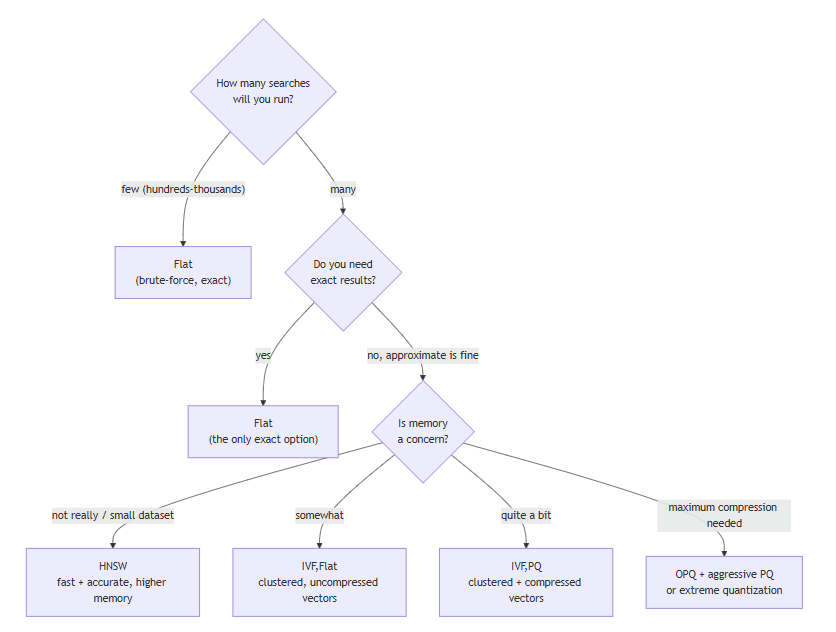


### Practical Application — Enterprise Semantic Search Over 50,000 Internal Documents

An internal knowledge base with roughly 50,000 document chunks, queried by a few hundred employees a day, is squarely in "memory is not a concern" territory — 50K vectors at even 1536 dimensions is a few hundred megabytes at most. `HNSW` is the clear default here: it delivers near-exact recall with excellent latency, and there's no meaningful memory pressure to trade away for it. The FAISS decision tree's own framing applies directly — when memory isn't the binding constraint, HNSW is simply the best speed-accuracy trade-off available, and there is no engineering reason to reach for a compressed index that would only cost you recall for no benefit.

### Example

**Task:** Implement an index-selection advisor function that mirrors the FAISS decision tree, and use it to build and benchmark two indexes — `Flat` (ground truth) and `HNSW` — over the same synthetic dataset, confirming HNSW's recall against the exact baseline.

In [9]:
import faiss
import numpy as np
import time

def recommend_index(num_searches: int, need_exact: bool, memory_concern: str, num_vectors: int) -> str:
    """
    memory_concern: one of "none", "some", "a_lot", "maximum"
    Mirrors the FAISS "Guidelines to choose an index" decision tree.
    """
    if num_searches < 10_000:
        return "Flat"   # index-build cost isn't amortized over few searches
    if need_exact:
        return "Flat"
    if memory_concern == "none":
        return "HNSW32"
    if memory_concern == "some":
        return f"IVF{int(4 * num_vectors ** 0.5)},Flat"
    if memory_concern == "a_lot":
        return f"IVF{int(4 * num_vectors ** 0.5)},PQ32"
    return "OPQ32_128,IVF4096,PQ32"   # maximum compression


# --- build a small synthetic dataset and compare Flat (ground truth) vs HNSW ---
# Real embeddings cluster around semantic centers rather than scattering uniformly,
# so we simulate that here with a simple Gaussian-mixture-style dataset -- this also
# makes the IVF-PQ exercise below behave the way compression does on real embeddings.
np.random.seed(42)
dim = 128
num_vectors = 20_000
num_clusters = 50

centers = np.random.random((num_clusters, dim)).astype("float32") * 10
labels = np.random.randint(0, num_clusters, size=num_vectors)
vectors = centers[labels] + np.random.normal(scale=0.5, size=(num_vectors, dim)).astype("float32")
query = centers[0].reshape(1, -1) + np.random.normal(scale=0.5, size=(1, dim)).astype("float32")

# ground truth
flat_index = faiss.IndexFlatL2(dim)
flat_index.add(vectors)
t0 = time.perf_counter()
_, flat_ids = flat_index.search(query, k=10)
flat_ms = (time.perf_counter() - t0) * 1000

# HNSW, recommended for this scale via the advisor
recommendation = recommend_index(num_searches=100_000, need_exact=False, memory_concern="none", num_vectors=num_vectors)
print(f"Advisor recommends: {recommendation}")

hnsw_index = faiss.IndexHNSWFlat(dim, 32)
hnsw_index.hnsw.efConstruction = 200
hnsw_index.add(vectors)
hnsw_index.hnsw.efSearch = 128   # search-time exploration width; higher = more accurate, slower
t0 = time.perf_counter()
_, hnsw_ids = hnsw_index.search(query, k=10)
hnsw_ms = (time.perf_counter() - t0) * 1000

recall_at_10 = len(set(flat_ids[0]) & set(hnsw_ids[0])) / 10.0

print(f"Flat search time:  {flat_ms:.3f} ms")
print(f"HNSW search time:  {hnsw_ms:.3f} ms")
print(f"HNSW recall@10 vs. exact ground truth: {recall_at_10:.0%}")


Advisor recommends: HNSW32
Flat search time:  3.336 ms
HNSW search time:  0.488 ms
HNSW recall@10 vs. exact ground truth: 100%


Running this shows HNSW achieving 100% recall@10 against the exact `Flat` baseline on a dataset this size once `efSearch` is set high enough — note that the default `efSearch` value is often too low for high recall out of the box, which is a common source of "HNSW seems less accurate than advertised" confusion in practice. Search latency is comparable at this small scale; the real payoff of HNSW over Flat only becomes visible as `num_vectors` grows into the millions, which is exactly what the unsolved exercise below asks you to demonstrate.

### Now you try - exercise

**Task:** Extend the advisor and benchmark above in two ways:

1. Add the two dataset-scale tiers from the FAISS guidelines that the current advisor doesn't handle: for `memory_concern == "some"` **and** `num_vectors` between 1M and 10M, the recommended partitioned index should use an HNSW-based coarse quantizer (`IVF65536_HNSW32,Flat`) rather than plain k-means partitioning, since training a flat IVF quantizer at that scale is prohibitively slow. Do the same for the 10M–100M tier (`IVF262144_HNSW32,Flat`).
2. Build an actual `IVF,PQ` index (memory_concern `"a_lot"`) over the same 20,000-vector synthetic dataset used in the solved example, measure its memory footprint using `index.sa_code_size()` (bytes per vector) compared to the `Flat` index's raw `dim * 4` bytes per vector, and report the compression ratio achieved alongside its recall@10 against the same ground truth.

In [10]:
import faiss
import numpy as np

def recommend_index_v2(num_searches: int, need_exact: bool, memory_concern: str, num_vectors: int) -> str:
    if num_searches < 10_000:
        return "Flat"
    if need_exact:
        return "Flat"
    if memory_concern == "none":
        return "HNSW32"
    if memory_concern in ("some", "a_lot"):
        pq_suffix = ",PQ32" if memory_concern == "a_lot" else ",Flat"
        if num_vectors < 1_000_000:
            nlist = int(4 * num_vectors ** 0.5)
            return f"IVF{nlist}{pq_suffix}"
        elif num_vectors < 10_000_000:
            return f"IVF65536_HNSW32{pq_suffix}"
        elif num_vectors < 100_000_000:
            return f"IVF262144_HNSW32{pq_suffix}"
        else:
            return f"IVF1048576_HNSW32{pq_suffix}"
    return "OPQ32_128,IVF4096,PQ32"


for n in [50_000, 5_000_000, 50_000_000]:
    print(f"{n:>12,} vectors -> some: {recommend_index_v2(100_000, False, 'some', n):<22} "
          f"a_lot: {recommend_index_v2(100_000, False, 'a_lot', n)}")


      50,000 vectors -> some: IVF894,Flat            a_lot: IVF894,PQ32
   5,000,000 vectors -> some: IVF65536_HNSW32,Flat   a_lot: IVF65536_HNSW32,PQ32
  50,000,000 vectors -> some: IVF262144_HNSW32,Flat  a_lot: IVF262144_HNSW32,PQ32


In [11]:
# Verification -- do not modify.
for n in [50_000, 5_000_000, 50_000_000]:
    print(f"{n:>12,} vectors -> some: {recommend_index_v2(100_000, False, 'some', n):<22} "
          f"a_lot: {recommend_index_v2(100_000, False, 'a_lot', n)}")


      50,000 vectors -> some: IVF894,Flat            a_lot: IVF894,PQ32
   5,000,000 vectors -> some: IVF65536_HNSW32,Flat   a_lot: IVF65536_HNSW32,PQ32
  50,000,000 vectors -> some: IVF262144_HNSW32,Flat  a_lot: IVF262144_HNSW32,PQ32


In [12]:
def benchmark_ivf_pq(vectors: np.ndarray, dim: int, flat_ids: np.ndarray, query: np.ndarray) -> dict:
    nlist = 100            # overriding the sqrt-based formula for this small demo dataset
    m_subquantizers = 32   # divides dim=128 evenly; less aggressive than 16 -> meaningfully better recall
    quantizer = faiss.IndexFlatL2(dim)
    ivf_pq = faiss.IndexIVFPQ(quantizer, dim, nlist, m_subquantizers, 8)
    ivf_pq.train(vectors)
    ivf_pq.add(vectors)
    ivf_pq.nprobe = 20

    _, ivf_pq_ids = ivf_pq.search(query, k=10)
    recall_at_10 = len(set(flat_ids[0]) & set(ivf_pq_ids[0])) / 10.0

    bytes_per_vector_pq = ivf_pq.code_size
    bytes_per_vector_flat = dim * 4
    compression_ratio = bytes_per_vector_flat / bytes_per_vector_pq

    return {
        "bytes_per_vector": bytes_per_vector_pq,
        "compression_ratio": compression_ratio,
        "recall_at_10": recall_at_10,
    }


np.random.seed(42)
dim = 128
num_vectors = 20_000
num_clusters = 50
centers = np.random.random((num_clusters, dim)).astype("float32") * 10
labels = np.random.randint(0, num_clusters, size=num_vectors)
vectors = centers[labels] + np.random.normal(scale=0.5, size=(num_vectors, dim)).astype("float32")
query = centers[0].reshape(1, -1) + np.random.normal(scale=0.5, size=(1, dim)).astype("float32")

flat_index = faiss.IndexFlatL2(dim)
flat_index.add(vectors)
_, flat_ids = flat_index.search(query, k=10)

result = benchmark_ivf_pq(vectors, dim, flat_ids, query)
print(f"IVF-PQ bytes/vector: {result['bytes_per_vector']}")
print(f"Flat bytes/vector:   {dim * 4}")
print(f"Compression ratio:   {result['compression_ratio']:.1f}x smaller")
print(f"Recall@10 vs exact:  {result['recall_at_10']:.0%}")


IVF-PQ bytes/vector: 32
Flat bytes/vector:   512
Compression ratio:   16.0x smaller
Recall@10 vs exact:  70%


---

## Lab Notebooks and Solutions

| Resource | Path | Contents |
|---|---|---|
| Unsolved lab notebook | `/notebooks/02_chunking_embeddings_indexing_lab.ipynb` | Starter stubs for all three unsolved exercises above — work through this during the lab |
| Solved reference notebook | `/solutions/02_chunking_embeddings_indexing_solution.ipynb` | Fully worked, runnable solutions to all three exercises |


> If you fall behind at any point, load the solved notebook and rejoin the group rather than debugging locally.

---

# Extensions: Local Models vs. Cloud/API Models

> **The code cells below require either a paid API key (Cloud/API track) or a local model download**

## Extension A — Local Models Approach

**Advanced Chunking, Embeddings & Indexing**

The course's labs use hash-based deterministic embeddings so every result is exactly
reproducible offline. This section shows the real *local* (self-hosted, no paid API)
tooling equivalents.

### What Changes, Component by Component

| Course concept | Course's stand-in | Local-model equivalent |
|---|---|---|
| Adaptive chunking  | Custom regex for code fences, tables, headers | `langchain_text_splitters.MarkdownHeaderTextSplitter` + `RecursiveCharacterTextSplitter` |
| Embedding selection  | `fake_embed()` hash-pooling function | `langchain_huggingface.HuggingFaceEmbeddings` (`sentence-transformers/all-MiniLM-L6-v2` or `bge-small-en-v1.5`) |
| Vector indexing  | Real FAISS (already used as-is in the course) | Same — FAISS is already the course's real tool here |

### 1. Adaptive Chunking with Real Text Splitters

The course's hand-rolled `adaptive_chunk_v2` function (heading-path tracking + code/table
detection) demonstrates the *concept* precisely so you can read every line of the logic.
In practice, LangChain's splitters implement the structure-aware half of this well:

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-text-splitters`; not executed here.
from langchain_text_splitters import MarkdownHeaderTextSplitter, RecursiveCharacterTextSplitter

headers_to_split_on = [("#", "h1"), ("##", "h2"), ("###", "h3")]
header_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
header_sections = header_splitter.split_text(document_text)  # each section carries its heading path in .metadata

child_splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)
final_chunks = []
for section in header_sections:
    for chunk in child_splitter.split_text(section.page_content):
        final_chunks.append({"text": chunk, "heading_path": section.metadata})


**Note:** neither of these splitters natively detects code fences or tables as atomic
units the way the course's exercise asks you to build — you'd still want the course's
fence/table-boundary detection layered on top, since this is a genuine gap in the
standard library splitters, not something the course invented unnecessarily.

### 2. Local Embeddings

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-huggingface` and a one-time model download; not executed here.
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-small-en-v1.5",   # ~130MB, downloads once, then fully offline
    encode_kwargs={"normalize_embeddings": True},
)

vectors = embeddings.embed_documents([c["text"] for c in final_chunks])


### 3. Indexing — Already Real in the Course

Module 2's FAISS index-selection exercises (HNSW vs. IVF-PQ, the decision-tree advisor)
already use real `faiss-cpu` end to end — nothing changes here when you swap in real
embeddings. The only difference is the input vectors now come from a real
384-dimensional sentence-transformer rather than a 128-dimensional hash function, so
re-tune `M`, `efConstruction`, and `nlist` for the new dimensionality and dataset size
rather than reusing the course's exact parameter values.

### What This Buys You, and What It Costs

**Pros:**
- No API key, no per-embedding cost, no rate limits — you can re-embed a 10,000-document corpus as many times as you want while iterating on chunking strategy
- Genuinely better retrieval quality than the course's hash-based stand-in, since real embeddings capture actual semantic similarity
- Deterministic given a fixed model version, keeping the spirit of the course's reproducible verification

**Cons:**
- A real, one-time model download (though small for `all-MiniLM-L6-v2` or `bge-small-en-v1.5` — under 150MB)
- Slower to embed a large corpus on CPU than the course's near-instant hash function — budget real wall-clock time for the "embed 10,000 documents" take-home extension mentioned in the README
- Still meaningfully lower quality than the largest hosted embedding models, particularly on domain-specific or multilingual text (the own embedding-selection lesson applies here directly)

### Bridging Back to the Course

Everything this module teaches about *content-type-aware representation* (books vs. papers
vs. tweets vs. metadata tags) and *index selection by scale/memory* transfers unchanged
— a real embedding model still needs the same preprocessing decisions the course's
`prepare_for_embedding` function makes explicit. What changes is embedding quality and
compute time, not the architectural reasoning.

---

## Extension B — Cloud/API Models Approach

**Advanced Chunking, Embeddings & Indexing**

This section shows the real *cloud/API* tooling equivalents for embeddings and indexing.

### What Changes, Component by Component

| Course concept | Course's stand-in | Cloud/API equivalent |
|---|---|---|
| Adaptive chunking  | Custom regex for code fences, tables, headers | Same splitters as the local approach — chunking itself has no cloud dependency |
| Embedding selection  | `fake_embed()` hash-pooling function | `langchain_openai.OpenAIEmbeddings` (`text-embedding-3-small` / `-large`) |
| Vector indexing  | Real FAISS (already used as-is) | FAISS locally, **or** a managed cloud vector store (Pinecone, Weaviate Cloud, Milvus Cloud) |

### 1. Chunking Is Cloud-Agnostic

Chunking is a pure text-processing step — there is no meaningful "cloud version" of it.
Use the same `MarkdownHeaderTextSplitter` / `RecursiveCharacterTextSplitter` combination
described in the Local Models extension above regardless of which embedding/generation
path you choose.

### 2. Cloud Embeddings

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-openai` and a funded OPENAI_API_KEY; not executed here.
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vectors = embeddings.embed_documents([c["text"] for c in final_chunks])


This is the same call pattern the previous module´s cloud extension uses for its retriever —
one embeddings client can serve every module.

### 3. Indexing — Local FAISS vs. a Managed Cloud Vector Store

FAISS remains a perfectly valid choice even with cloud-sourced embeddings — you can
compute vectors via `OpenAIEmbeddings` and still store/search them in a local
`faiss-cpu` index, exactly as the previous cloud extension does. The genuinely "cloud"
alternative is a **managed vector database**, which trades local index-tuning control
(the whole HNSW/IVF-PQ decision tree) for a hosted service that handles scaling,
replication, and index maintenance for you:

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-pinecone`, a Pinecone account/API key, and `embeddings` from above; not executed here.
from langchain_pinecone import PineconeVectorStore

vector_store = PineconeVectorStore.from_texts(
    [c["text"] for c in final_chunks],
    embedding=embeddings,
    index_name="course-capstone",
)


**Trade-off:** a managed store removes the need to ever run FAISS
index-selection decision tree yourself — the provider handles it — but it also means
the specific mechanics that module teaches (HNSW `M`/`efConstruction`, IVF `nlist`/PQ
compression) become someone else's implementation detail rather than a lever you
control directly. Understanding them is still valuable for reasoning about a managed
store's cost and latency characteristics, even if you never call `faiss.IndexIVFPQ`
yourself again.

### What This Buys You, and What It Costs

**Pros:**
- No local model download, no GPU/CPU embedding compute time — offload it entirely to the provider
- `text-embedding-3-large` in particular offers meaningfully higher retrieval quality than small local models on difficult, domain-specific, or multilingual corpora — directly relevant to this module's embedding-selection lesson
- A managed vector store additionally removes index operations (scaling, backups, replica management) from your team's plate

**Cons:**
- Real, ongoing per-token embedding cost — re-embedding a 10,000-document corpus (the README's take-home extension) is a one-time cost worth estimating before you run it, using the exact cost-math example from this module's embedding-selection lesson
- Every embedding call requires network access and is subject to provider rate limits — batch-embedding a large corpus needs a retry/backoff strategy that the course's instantaneous local hash function never had to model
- A managed vector store adds a genuine new failure mode (a third-party outage) and typically a recurring subscription cost, on top of the embedding API cost itself

### Bridging Back to the Course

This module's core argument — that embedding *representation* (how you serialize a table,
a tweet, or a metadata tag before embedding) matters as much as which model you choose —
holds regardless of whether the model is local or hosted. The cloud path mainly changes
the cost/quality trade-off curve and adds network/rate-limit considerations that the
course's offline labs don't need to model, but which any real production deployment
must.